# Brain age prediction on MS data (smoothed asymmetry, m120 scans)

## Imports and paths

In [1]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
import nibabel as nib
import matplotlib.pyplot as plt
import pyreadstat

# fastMONAI / fastai / MONAI
from fastMONAI.vision_all import *
from fastai.learner import Learner
from fastai.losses import L1LossFlat
from fastai.metrics import mae
from monai.networks.nets import Regressor

/opt/conda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Root directory for thesis project
ms_root = Path("/hus/home/aaasen/Master_thesis")

image_dir = ms_root / "VBM_project_MS_m120" / "T1_scans"

# Metadata file (participants / clinical info)
ms_participants_path = ms_root / "Metadata_OFAMS" / "follow_up_info.csv"

## Load MS metadata

In [3]:
df_part = pd.read_csv(ms_participants_path)
df_part.head()

,Unnamed: 0,Patnr,Sex_OFAMS10,Age_BL_OFAMS,Age_OFAMS10,EDSS_score_10
0,1,101,1.0,35.0,47.0,2
1,2,103,0.0,24.0,36.0,1
2,3,104,1.0,48.0,59.0,"1,5"
3,4,201,0.0,50.0,62.0,2
4,5,202,1.0,31.0,43.0,0


In [4]:
df_part.dtypes

Unnamed: 0         int64
Patnr              int64
Sex_OFAMS10      float64
Age_BL_OFAMS     float64
Age_OFAMS10      float64
EDSS_score_10     object
dtype: object

In [5]:
df_part = df_part.rename(columns={
    'Patnr': 'participant_id',
    'Sex_OFAMS10': 'sex',
    'Age_OFAMS10': 'age_10Yrs',
    'EDSS_score_10': 'EDSS_10Yrs'})

df_part = df_part.drop(columns=["Unnamed: 0"])
df_part = df_part.drop(columns=["Age_BL_OFAMS"])
df_part["sex"] = df_part["sex"].map({0: "M", 1: "F"}) # 1=female, 0=male

In [6]:
df_part.head()

,participant_id,sex,age_10Yrs,EDSS_10Yrs
0,101,F,47.0,2
1,103,M,36.0,1
2,104,F,59.0,"1,5"
3,201,M,62.0,2
4,202,F,43.0,0


In [7]:
df_part["EDSS_10Yrs"] = (df_part["EDSS_10Yrs"].str.strip().str.replace(",", ".", regex=False))
df_part["EDSS_10Yrs"] = pd.to_numeric(df_part["EDSS_10Yrs"], errors="coerce")

In [8]:
df_part.dtypes

participant_id      int64
sex                object
age_10Yrs         float64
EDSS_10Yrs        float64
dtype: object

In [9]:
print(f"Number with m120-EDSS: {df_part["EDSS_10Yrs"].notna().sum()} / {df_part["participant_id"].notna().sum()}")
df_part.head()

Number with m120-EDSS: 84 / 92


,participant_id,sex,age_10Yrs,EDSS_10Yrs
0,101,F,47.0,2.0
1,103,M,36.0,1.0
2,104,F,59.0,1.5
3,201,M,62.0,2.0
4,202,F,43.0,0.0


## Remove subjects with missing age

In [10]:
# Removing rows with NaN values in age_10Yrs (age at m120-scans)
df_part = df_part.dropna(subset=["age_10Yrs"])
df_part.head()

,participant_id,sex,age_10Yrs,EDSS_10Yrs
0,101,F,47.0,2.0
1,103,M,36.0,1.0
2,104,F,59.0,1.5
3,201,M,62.0,2.0
4,202,F,43.0,0.0


In [11]:
min_age_new = df_part["age_10Yrs"].min()
max_age_new = df_part["age_10Yrs"].max()

print("Ages at m120-scans:")
print(f"Min age: {min_age_new}")
print(f"Max age: {max_age_new}")

Ages at m120-scans:
Min age: 31.0
Max age: 70.0


## Build dataframe linking images to subject metadata

In [12]:
from pathlib import Path
import pandas as pd

rows = []

# Finn alle m120 step4_warped-filer rekursivt
# Bytt pattern hvis asymmetrifilene dine har annet navn.
image_paths = sorted(image_dir.rglob("m120/mri/step4_warped/sAI_mwrp1sub-*_ses-m120_ce-GADOLINIUM_*_affine.nii*"))

print("Found image files:", len(image_paths))
if len(image_paths) > 0:
    print("Example:", image_paths[0])

for p in image_paths:
    fname = p.name

    # 1) Prøv å hente ID fra filnavn: "...sub-101..."
    participant_id = None
    if "sub-" in fname:
        try:
            participant_id = fname.split("sub-")[1].split("_")[0]
        except IndexError:
            participant_id = None

    # 2) Fallback: hent ID fra mappestruktur: .../T1_scans/101/m120/...
    if participant_id is None:
        # p.parts inneholder alle mappenavn i stien
        # Finn indeksen til "T1_scans" og ta neste element (= subject folder, f.eks. "101")
        parts = p.parts
        if "T1_scans" in parts:
            i = parts.index("T1_scans")
            if i + 1 < len(parts):
                participant_id = parts[i + 1]

    if participant_id is None:
        print("Could not parse subject ID from:", p)
        continue

    # Match metadata
    match = df_part[df_part["participant_id"].astype(str) == str(participant_id)]

    if len(match) == 1:
        rows.append({
            "image_path": str(p),
            "participant_id": str(participant_id),
            "sex": match["sex"].values[0],
            "age_10Yrs": match["age_10Yrs"].values[0],
            "EDSS_10Yrs": match["EDSS_10Yrs"].values[0],
        })
    else:
        print("Metadata not found (or not unique) for subject:", participant_id, "matches:", len(match))

df_ms = pd.DataFrame(rows)

print("Number of MS scans:", len(df_ms))
df_ms.head()

Found image files: 75
Example: /hus/home/aaasen/Master_thesis/VBM_project_MS_m120/T1_scans/101/m120/mri/step4_warped/sAI_mwrp1sub-101_ses-m120_ce-GADOLINIUM_FLASH_affine.nii
Number of MS scans: 75


,image_path,participant_id,sex,age_10Yrs,EDSS_10Yrs
0,/hus/home/aaasen/Master_thesis/VBM_project_MS_m120/T1_scans/101/m120/mri/step4_warped/sAI_mwrp1sub-101_ses-m120_ce-GADOLINIUM_FLASH_affine.nii,101,F,47.0,2.0
1,/hus/home/aaasen/Master_thesis/VBM_project_MS_m120/T1_scans/103/m120/mri/step4_warped/sAI_mwrp1sub-103_ses-m120_ce-GADOLINIUM_FLASH_affine.nii,103,M,36.0,1.0
2,/hus/home/aaasen/Master_thesis/VBM_project_MS_m120/T1_scans/104/m120/mri/step4_warped/sAI_mwrp1sub-104_ses-m120_ce-GADOLINIUM_FLASH_affine.nii,104,F,59.0,1.5
3,/hus/home/aaasen/Master_thesis/VBM_project_MS_m120/T1_scans/1101/m120/mri/step4_warped/sAI_mwrp1sub-1101_ses-m120_ce-GADOLINIUM_FLASH_affine.nii,1101,F,58.0,2.5
4,/hus/home/aaasen/Master_thesis/VBM_project_MS_m120/T1_scans/1102/m120/mri/step4_warped/sAI_mwrp1sub-1102_ses-m120_ce-GADOLINIUM_FLASH_affine.nii,1102,F,51.0,5.0


## Build DataBlock

In [13]:
import pickle
from pathlib import Path

# Path til lagrede preprocessing-parametere
preproc_path = Path("/hus/home/aaasen/Master_thesis/smoothed_model/smoothed_preproc_params.pkl")

with open(preproc_path, "rb") as f:
    preproc = pickle.load(f)

resample = preproc["resample"]
reorder  = preproc["reorder"]

print("Preprocessing parameters loaded successfully.")
print("Resample:", resample)
print("Reorder:", reorder)

Preprocessing parameters loaded successfully.
Resample: [1.5, 1.5, 1.5]
Reorder: False


In [14]:
# Identical to baseline_train
in_shape = [1, 128, 160, 128]

item_tfms = [ZNormalization(), PadOrCrop(in_shape[1:])]

In [15]:
dblock = MedDataBlock(
    blocks=(ImageBlock(cls=MedImage), RegressionBlock),
    splitter=None,  # no splitting for inference
    get_x=ColReader("image_path"),
    get_y=ColReader("age_10Yrs"),  # used only for analysis
    item_tfms=item_tfms,
    apply_reorder=reorder,
    target_spacing=resample
)

dls = dblock.dataloaders(df_ms, bs=4)

## Load model

In [16]:
model = Regressor(
    in_shape=in_shape,
    out_shape=1,
    channels=(64, 128, 256, 256, 256),
    strides=(2, 2, 2, 2),
    kernel_size=3,
    num_res_units=2
)

In [17]:
learn = Learner(
    dls,
    model,
    loss_func=L1LossFlat(), 
    metrics=[mae],
)

from pathlib import Path

learn.path = Path("/hus/home/aaasen/Master_thesis/smoothed_model")
learn.model_dir = ""   # siden filen ligger direkte i mappen

# Load trained weights
learn.load("smoothed_baseline_best")

Saved file doesn't contain an optimizer state.


In [18]:
learn.model.eval()

Regressor(
  (net): Sequential(
    (layer_0): ResidualUnit(
      (conv): Sequential(
        (unit0): Convolution(
          (conv): Conv3d(1, 64, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
          (adn): ADN(
            (N): InstanceNorm3d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (A): PReLU(num_parameters=1)
          )
        )
        (unit1): Convolution(
          (conv): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (adn): ADN(
            (N): InstanceNorm3d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (A): PReLU(num_parameters=1)
          )
        )
      )
      (residual): Conv3d(1, 64, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
    )
    (layer_1): ResidualUnit(
      (conv): Sequential(
        (unit0): Convolution(
          (conv): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
         

## Brain age predictions and brain age gap

In [19]:
test_dl = dls.test_dl(df_ms, with_labels=True)

In [20]:
preds, targs = learn.get_preds(dl=test_dl) # test = the whole dataset when splitter=None

y_pred = preds.squeeze().cpu().numpy()
y_true = targs.squeeze().cpu().numpy()

df_ms["predicted_age"] = y_pred
df_ms["brain_age_gap"] = y_pred - df_ms["age_10Yrs"]

df_ms.head()

,image_path,participant_id,sex,age_10Yrs,EDSS_10Yrs,predicted_age,brain_age_gap
0,/hus/home/aaasen/Master_thesis/VBM_project_MS_m120/T1_scans/101/m120/mri/step4_warped/sAI_mwrp1sub-101_ses-m120_ce-GADOLINIUM_FLASH_affine.nii,101,F,47.0,2.0,55.467602,8.467602
1,/hus/home/aaasen/Master_thesis/VBM_project_MS_m120/T1_scans/103/m120/mri/step4_warped/sAI_mwrp1sub-103_ses-m120_ce-GADOLINIUM_FLASH_affine.nii,103,M,36.0,1.0,35.228588,-0.771412
2,/hus/home/aaasen/Master_thesis/VBM_project_MS_m120/T1_scans/104/m120/mri/step4_warped/sAI_mwrp1sub-104_ses-m120_ce-GADOLINIUM_FLASH_affine.nii,104,F,59.0,1.5,50.703156,-8.296844
3,/hus/home/aaasen/Master_thesis/VBM_project_MS_m120/T1_scans/1101/m120/mri/step4_warped/sAI_mwrp1sub-1101_ses-m120_ce-GADOLINIUM_FLASH_affine.nii,1101,F,58.0,2.5,64.428452,6.428452
4,/hus/home/aaasen/Master_thesis/VBM_project_MS_m120/T1_scans/1102/m120/mri/step4_warped/sAI_mwrp1sub-1102_ses-m120_ce-GADOLINIUM_FLASH_affine.nii,1102,F,51.0,5.0,55.185246,4.185246


## Bias correction

In [21]:
# Load bias correction parameters estimated on train set
a, b = np.load("smoothed_bias_correction_params.npy")
y_pred_bc = (y_pred - b) / a

df_ms["predicted_age_bc"] = (df_ms["predicted_age"] - b) / a
df_ms["brain_age_gap_bc"] = df_ms["predicted_age_bc"] - df_ms["age_10Yrs"]

In [22]:
df_ms.head()

,image_path,participant_id,sex,age_10Yrs,EDSS_10Yrs,predicted_age,brain_age_gap,predicted_age_bc,brain_age_gap_bc
0,/hus/home/aaasen/Master_thesis/VBM_project_MS_m120/T1_scans/101/m120/mri/step4_warped/sAI_mwrp1sub-101_ses-m120_ce-GADOLINIUM_FLASH_affine.nii,101,F,47.0,2.0,55.467602,8.467602,55.830288,8.830288
1,/hus/home/aaasen/Master_thesis/VBM_project_MS_m120/T1_scans/103/m120/mri/step4_warped/sAI_mwrp1sub-103_ses-m120_ce-GADOLINIUM_FLASH_affine.nii,103,M,36.0,1.0,35.228588,-0.771412,35.893356,-0.106644
2,/hus/home/aaasen/Master_thesis/VBM_project_MS_m120/T1_scans/104/m120/mri/step4_warped/sAI_mwrp1sub-104_ses-m120_ce-GADOLINIUM_FLASH_affine.nii,104,F,59.0,1.5,50.703156,-8.296844,51.136955,-7.863045
3,/hus/home/aaasen/Master_thesis/VBM_project_MS_m120/T1_scans/1101/m120/mri/step4_warped/sAI_mwrp1sub-1101_ses-m120_ce-GADOLINIUM_FLASH_affine.nii,1101,F,58.0,2.5,64.428452,6.428452,64.657387,6.657387
4,/hus/home/aaasen/Master_thesis/VBM_project_MS_m120/T1_scans/1102/m120/mri/step4_warped/sAI_mwrp1sub-1102_ses-m120_ce-GADOLINIUM_FLASH_affine.nii,1102,F,51.0,5.0,55.185246,4.185246,55.552147,4.552147


## Prediction results

In [23]:
print(df_ms[["participant_id", "sex", "age_10Yrs", "predicted_age", "brain_age_gap", "predicted_age_bc", "brain_age_gap_bc", "EDSS_10Yrs"]].head())
print("N =", len(df_ms))
print("Mean BAG:", df_ms["brain_age_gap"].mean())
print("Mean BAG (bias-corrected):", df_ms["brain_age_gap_bc"].mean())
print("Std BAG:", df_ms["brain_age_gap"].std())
print("Std BAG (bias-corrected):", df_ms["brain_age_gap_bc"].std())

  participant_id sex  age_10Yrs  predicted_age  brain_age_gap  \
0            101   F       47.0      55.467602       8.467602   
1            103   M       36.0      35.228588      -0.771412   
2            104   F       59.0      50.703156      -8.296844   
3           1101   F       58.0      64.428452       6.428452   
4           1102   F       51.0      55.185246       4.185246   

   predicted_age_bc  brain_age_gap_bc  EDSS_10Yrs  
0         55.830288          8.830288         2.0  
1         35.893356         -0.106644         1.0  
2         51.136955         -7.863045         1.5  
3         64.657387          6.657387         2.5  
4         55.552147          4.552147         5.0  
N = 75
Mean BAG: 3.2818275197347004
Mean BAG (bias-corrected): 3.67793332417806
Std BAG: 10.059689238272078
Std BAG (bias-corrected): 9.960317008325918


## Quality Control (QC)

### Extreme outliers

Checking if the huge BAG is due to wrongfully done preprocessing, empty image etc. Manually checking these images.

In [24]:
df_ms.sort_values("brain_age_gap", key=lambda x: abs(x), ascending=False).head(5)

,image_path,participant_id,sex,age_10Yrs,EDSS_10Yrs,predicted_age,brain_age_gap,predicted_age_bc,brain_age_gap_bc
15,/hus/home/aaasen/Master_thesis/VBM_project_MS_m120/T1_scans/1406/m120/mri/step4_warped/sAI_mwrp1sub-1406_ses-m120_ce-GADOLINIUM_FLASH_affine.nii,1406,F,37.0,2.5,60.745052,23.745052,61.028969,24.028969
22,/hus/home/aaasen/Master_thesis/VBM_project_MS_m120/T1_scans/1414/m120/mri/step4_warped/sAI_mwrp1sub-1414_ses-m120_ce-GADOLINIUM_FLASH_affine.nii,1414,F,38.0,4.0,60.228924,22.228924,60.520542,22.520542
56,/hus/home/aaasen/Master_thesis/VBM_project_MS_m120/T1_scans/705/m120/mri/step4_warped/sAI_mwrp1sub-705_ses-m120_ce-GADOLINIUM_FLASH_affine.nii,705,F,31.0,4.5,51.050880,20.050880,51.479488,20.479488
52,/hus/home/aaasen/Master_thesis/VBM_project_MS_m120/T1_scans/606/m120/mri/step4_warped/sAI_mwrp1sub-606_ses-m120_ce-GADOLINIUM_FLASH_affine.nii,606,M,44.0,6.5,63.918362,19.918362,64.154907,20.154907
64,/hus/home/aaasen/Master_thesis/VBM_project_MS_m120/T1_scans/805/m120/mri/step4_warped/sAI_mwrp1sub-805_ses-m120_ce-GADOLINIUM_FLASH_affine.nii,805,F,57.0,2.0,38.348976,-18.651024,38.967171,-18.032829


Conclution: Nothing unusual with these asymmetry images.

In [25]:
# checking the input shape
xb, _ = dls.one_batch()
print(xb.shape)

torch.Size([4, 1, 128, 160, 128])


### Visualizing the 10 subjects with the largest and smallest BAG

Checking the visualizations if anything looks unusual.

In [26]:
# Top 10 best and worst predictions (abs bias-corrected error)
best_cases = df_ms.sort_values("brain_age_gap").head(10)
worst_cases = df_ms.sort_values("brain_age_gap", ascending=False).head(10)

In [27]:
best_cases[
    ["participant_id", "sex", "age_10Yrs", "predicted_age", "predicted_age_bc", "brain_age_gap", "brain_age_gap_bc", "EDSS_10Yrs"]
    ]

,participant_id,sex,age_10Yrs,predicted_age,predicted_age_bc,brain_age_gap,brain_age_gap_bc,EDSS_10Yrs
64,805,F,57.0,38.348976,38.967171,-18.651024,-18.032829,2.0
71,814,F,54.0,37.183220,37.818813,-16.816780,-16.181187,5.5
72,815,M,56.0,40.172947,40.763916,-15.827053,-15.236084,1.0
41,301,F,47.0,31.264410,31.988344,-15.735590,-15.011656,6.0
74,904,F,57.0,42.248787,42.808773,-14.751213,-14.191227,2.5
50,603,F,66.0,51.640007,52.059822,-14.359993,-13.940178,4.0
42,302,F,55.0,42.913715,43.463776,-12.086285,-11.536224,2.0
12,1402,F,56.0,44.627178,45.151665,-11.372822,-10.848335,2.0
19,1410,F,58.0,46.734055,47.227093,-11.265945,-10.772907,1.5
53,701,F,48.0,38.835342,39.446278,-9.164658,-8.553722,3.0


In [28]:
worst_cases[
    ["participant_id", "sex", "age_10Yrs", "predicted_age", "predicted_age_bc", "brain_age_gap", "brain_age_gap_bc", "EDSS_10Yrs"]
    ]

,participant_id,sex,age_10Yrs,predicted_age,predicted_age_bc,brain_age_gap,brain_age_gap_bc,EDSS_10Yrs
15,1406,F,37.0,60.745052,61.028969,23.745052,24.028969,2.5
22,1414,F,38.0,60.228924,60.520542,22.228924,22.520542,4.0
56,705,F,31.0,51.050880,51.479488,20.050880,20.479488,4.5
52,606,M,44.0,63.918362,64.154907,19.918362,20.154907,6.5
5,1103,F,45.0,62.808647,63.061764,17.808647,18.061764,2.5
8,1106,F,33.0,49.467327,49.919571,16.467327,16.919571,2.5
43,303,F,38.0,54.337101,54.716660,16.337101,16.716660,4.0
11,1203,M,43.0,58.424377,58.742931,15.424377,15.742931,3.0
60,709,F,46.0,61.155315,61.433109,15.155315,15.433109,2.0
51,604,M,55.0,69.958038,70.104446,14.958038,15.104446,3.5


In [29]:
def show_asymmetry_image(image_path, title=None, slice_idx=None):
    img = nib.load(image_path).get_fdata()

    # Default: mid axial slice
    if slice_idx is None:
        slice_idx = img.shape[2] // 2

    plt.figure(figsize=(4, 4))
    plt.imshow(img[:, :, slice_idx].T, cmap="bwr", origin="lower")
    plt.colorbar(fraction=0.046)
    if title is not None:
        plt.title(title)
    plt.axis("off")
    plt.show()

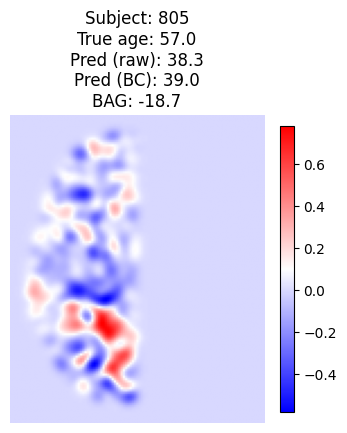

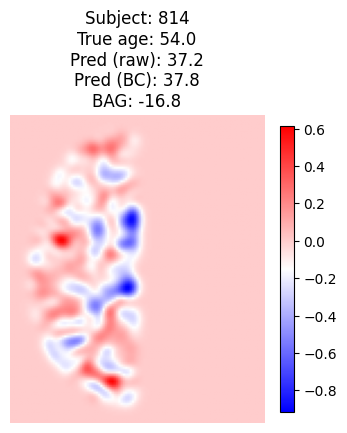

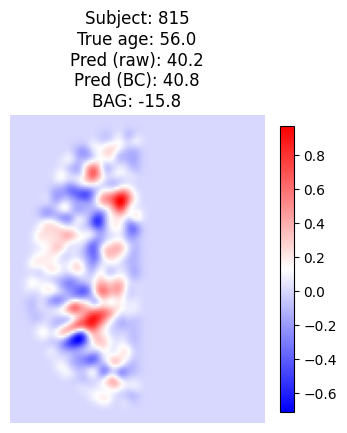

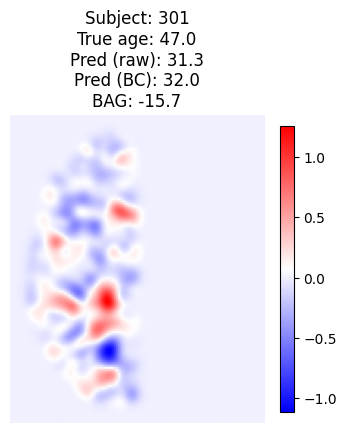

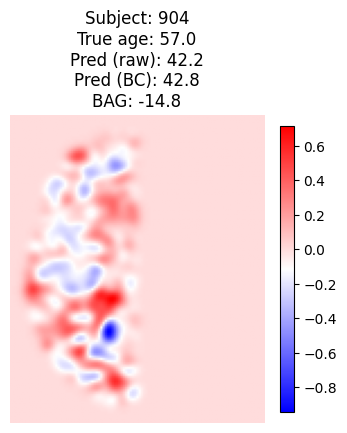

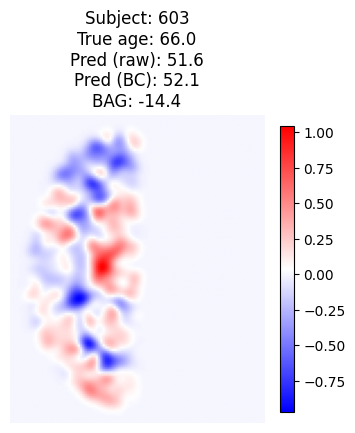

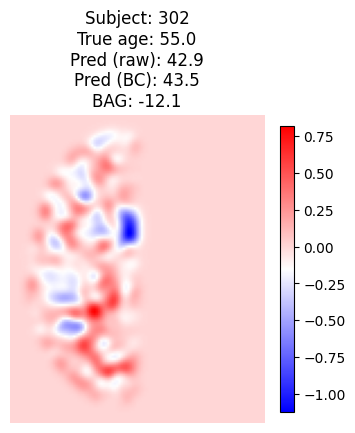

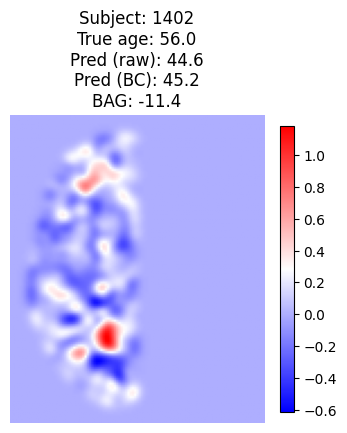

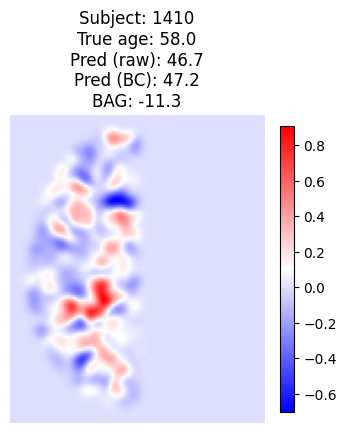

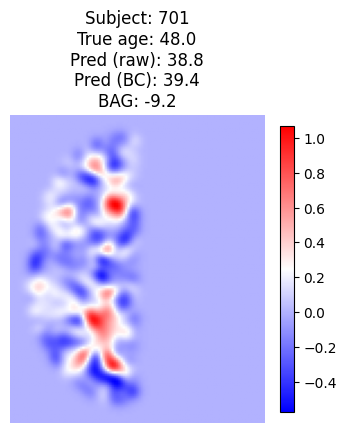

In [30]:
# Best cases sorted after bias-corrected predictions (smallest BAG)
for _, row in best_cases.iterrows():
    title = (
    f"Subject: {row['participant_id']}\n"
    f"True age: {row['age_10Yrs']:.1f}\n"
    f"Pred (raw): {row['predicted_age']:.1f}\n"
    f"Pred (BC): {row['predicted_age_bc']:.1f}\n"
    f"BAG: {row['brain_age_gap']:.1f}")

    show_asymmetry_image(row["image_path"], title=title)

# red/positive values: rightward asymmetry
# blue/negative values: leftward asymmetry

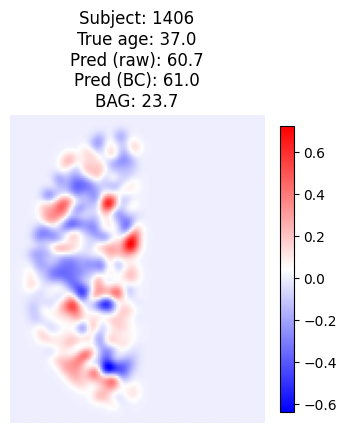

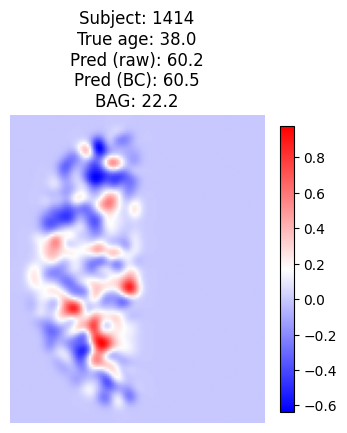

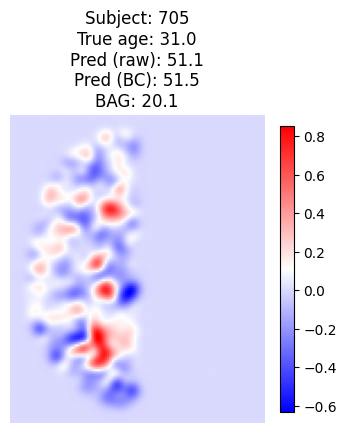

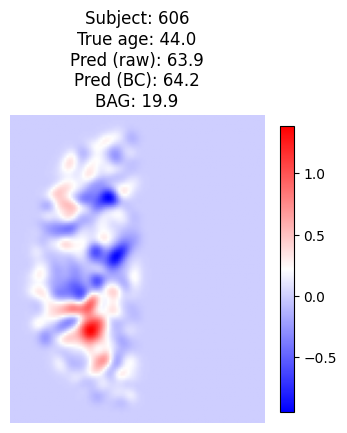

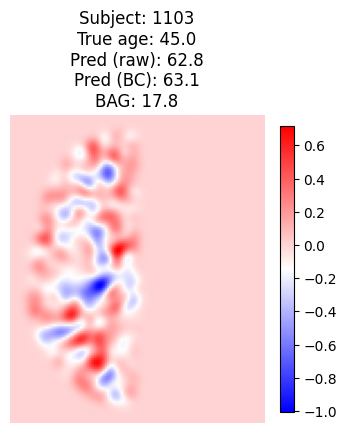

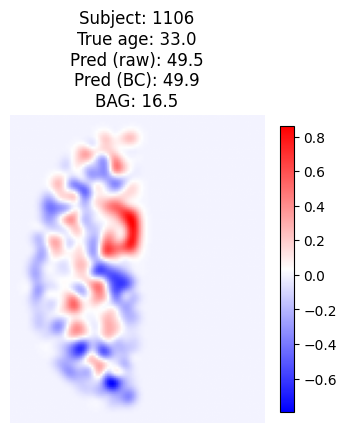

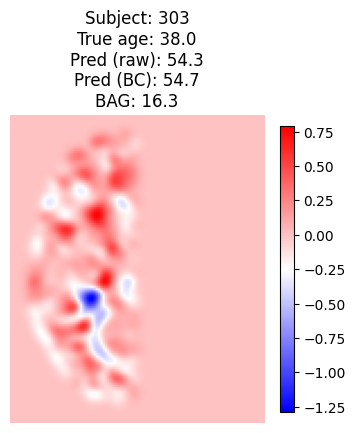

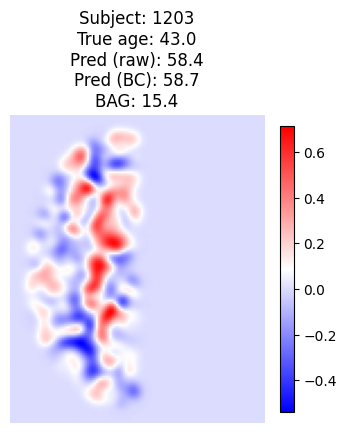

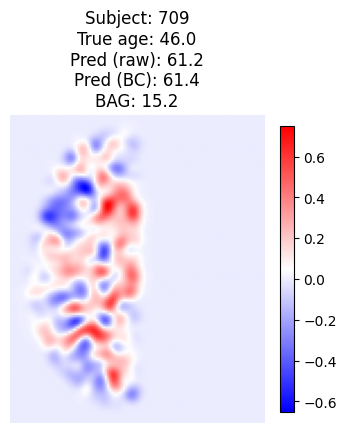

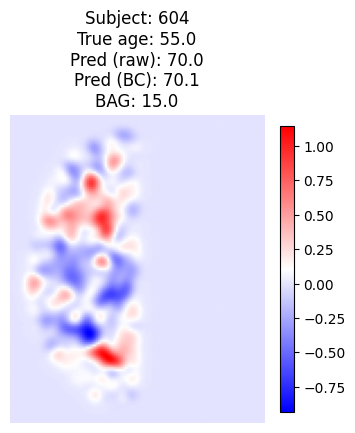

In [31]:
# Worst cases sorted after bias-corrected predictions (largest BAG)
for _, row in worst_cases.iterrows():
    title = (
    f"Subject: {row['participant_id']}\n"
    f"True age: {row['age_10Yrs']:.1f}\n"
    f"Pred (raw): {row['predicted_age']:.1f}\n"
    f"Pred (BC): {row['predicted_age_bc']:.1f}\n"
    f"BAG: {row['brain_age_gap']:.1f}")

    show_asymmetry_image(row["image_path"], title=title)

Conclusions: Nothing suspicious.

## Save results

In [60]:
#df_ms.to_csv("smoothed_MS_brain_age_predictions_m120.csv", index=False)